# FABN Bond Universe — Summary Statistics, Correlation, and Significance Tests

This notebook generates the quantitative tables and figures needed for the Data section of the capstone paper:

1. Summary statistics (counts by rating, counts by sector, average duration, average spread)
2. Pairwise correlation matrix across bond-level numeric attributes, with significance (p-values)
3. Significance tests for spread differences across rating and sector cohorts

All outputs are saved to an `outputs/` folder as `.tex` tables (booktabs format, ready for `\input{}`) and a `.png` figure, matching the file names referenced in the updated LaTeX Data section.

Schema confirmed directly against `insurance-backed-securities.Securities` on 2026-07-11: bond id is `CUSIP`, rating is `BBG Composite`, sector is `BICS_LEVEL_1_SECTOR_NAME`, duration is `Mac Dur _Ask_`, coupon is `Cpn`. There's no years-to-maturity column, so it's derived from the `Maturity` date field. If the schema changes later, the query cell in Section 1 is where to edit.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

sns.set_style("whitegrid")


In [2]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
# Confirmed against the actual Agg_Fixed_Field / Agg_Spread_Long schema in
# insurance-backed-securities.Securities (checked directly on 2026-07-11).
CONFIG = {
    "use_bigquery": True,          # set False to load from a local CSV instead
    "project_id": "insurance-backed-securities",
    "dataset": "Securities",
    "static_table": "Agg_Fixed_Field",   # issuer, rating, sector, duration, coupon, maturity
    "spread_table": "Agg_Spread_Long",   # long-format daily spreads

    "local_csv_path": "bond_universe.csv",       # used only if use_bigquery = False
}

# Note on schema: bond id is CUSIP (not ISIN), rating is "BBG Composite" (with
# a space), duration is "Mac Dur _Ask_", coupon is "Cpn". There is no
# years-to-maturity column directly -- it's derived below from the Maturity
# DATE field. Column names with spaces/parentheses need backticks in the
# query below, which is why they're hardcoded rather than templated from CONFIG.


## 1. Load Data

In [3]:
if CONFIG["use_bigquery"]:
    from google.cloud import bigquery
    client = bigquery.Client(project=CONFIG["project_id"])

    query = f"""
    WITH latest_spread AS (
        SELECT
            CUSIP AS bond_id,
            Spread AS spread,
            ROW_NUMBER() OVER (
                PARTITION BY CUSIP
                ORDER BY Date DESC
            ) AS rn
        FROM `{CONFIG['project_id']}.{CONFIG['dataset']}.{CONFIG['spread_table']}`
    )
    SELECT
        s.CUSIP AS bond_id,
        s.`BBG Composite` AS rating,
        s.BICS_LEVEL_1_SECTOR_NAME AS sector,
        s.`Mac Dur _Ask_` AS duration,
        s.Cpn AS coupon,
        DATE_DIFF(s.Maturity, CURRENT_DATE(), DAY) / 365.25 AS maturity_years,
        l.spread AS spread
    FROM `{CONFIG['project_id']}.{CONFIG['dataset']}.{CONFIG['static_table']}` s
    JOIN latest_spread l
        ON s.CUSIP = l.bond_id
    WHERE l.rn = 1
    """

    df = client.query(query).to_dataframe()
else:
    df = pd.read_csv(CONFIG["local_csv_path"])

print(df.shape)
df.head()


/opt/anaconda3/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(303, 7)


,bond_id,rating,sector,duration,coupon,maturity_years,spread
0,58769JAQ0,A,Consumer Discretionary,0.835555,4.80,0.498289,24.793151
1,YT2012888,A,Consumer Discretionary,3.366354,5.10,3.342916,56.715571
2,05565ECH6,A,Consumer Discretionary,1.036919,4.90,0.720055,31.377771
3,233835AQ0,A,Consumer Discretionary,4.119051,8.50,4.517454,71.339472
4,58769JAC1,A,Consumer Discretionary,1.656148,5.25,1.379877,39.444185


In [4]:
# Basic cleaning: drop rows missing rating, sector, duration, or spread
df = df.dropna(subset=["rating", "sector", "duration", "spread"]).copy()

# Fix any sign-flip errors in spread (same convention as the main pipeline)
df["spread"] = df["spread"].abs()

# Spread-per-duration, used in Figure 5 of the paper
df["spread_per_duration"] = df["spread"] / df["duration"]

len(df)


303

## 2. Summary Statistics

In [5]:
summary_by_rating = (
    df.groupby("rating")
      .agg(n_bonds=("bond_id", "count"),
           avg_duration=("duration", "mean"),
           avg_spread=("spread", "mean"),
           std_spread=("spread", "std"))
      .round(2)
      .sort_values("avg_spread")
)
summary_by_rating.columns = ["N", "Avg. Duration (yr)", "Avg. Spread (bps)", "Std. Spread (bps)"]
summary_by_rating


,N,Avg. Duration (yr),Avg. Spread (bps),Std. Spread (bps)
rating,,,,
AAA,14,2.17,12.74,8.58
AA,6,2.39,28.24,28.61
AA-,30,1.77,30.01,14.33
AA+,11,1.84,31.63,15.12
A,69,2.03,36.32,18.15
A+,53,2.29,42.68,20.30
A-,42,1.84,49.29,17.24
BBB+,34,2.47,64.30,19.87
BBB,30,2.25,67.79,20.51


In [6]:
summary_by_sector = (
    df.groupby("sector")
      .agg(n_bonds=("bond_id", "count"),
           avg_duration=("duration", "mean"),
           avg_spread=("spread", "mean"),
           std_spread=("spread", "std"))
      .round(2)
      .sort_values("N" if "N" in df.columns else "n_bonds", ascending=False)
)
summary_by_sector.columns = ["N", "Avg. Duration (yr)", "Avg. Spread (bps)", "Std. Spread (bps)"]
summary_by_sector


,N,Avg. Duration (yr),Avg. Spread (bps),Std. Spread (bps)
sector,,,,
Financials,173,1.96,47.08,24.27
Industrials,32,2.19,33.54,16.85
Consumer Discretionary,28,2.54,45.24,19.85
Energy,16,2.35,48.24,25.68
Utilities,15,1.96,55.08,25.76
Communications,9,3.32,58.48,28.32
Government,8,2.66,26.35,31.25
Consumer Staples,7,1.72,20.84,18.18
Materials,7,2.34,64.61,8.64


In [7]:
overall = pd.DataFrame({
    "N": [len(df)],
    "Avg. Duration (yr)": [round(df["duration"].mean(), 2)],
    "Avg. Spread (bps)": [round(df["spread"].mean(), 2)],
    "Std. Spread (bps)": [round(df["spread"].std(), 2)],
})
overall


,N,Avg. Duration (yr),Avg. Spread (bps),Std. Spread (bps)
0,303,2.11,45.43,24.17


In [8]:
# Export to booktabs-style LaTeX tables, ready for \input{} in the paper
summary_by_rating.to_latex("outputs/tables/summary_by_rating.tex")
summary_by_sector.to_latex("outputs/tables/summary_by_sector.tex")
overall.to_latex("outputs/tables/summary_overall.tex", index=False)

print("Saved: outputs/tables/summary_by_rating.tex")
print("Saved: outputs/tables/summary_by_sector.tex")
print("Saved: outputs/tables/summary_overall.tex")


Saved: outputs/tables/summary_by_rating.tex
Saved: outputs/tables/summary_by_sector.tex
Saved: outputs/tables/summary_overall.tex


## 3. Correlation Matrix

Pairwise Pearson correlation across bond-level numeric attributes, with a companion matrix of p-values.

In [9]:
numeric_cols = ["spread", "duration", "coupon", "maturity_years"]
corr_df = df[numeric_cols].dropna()

corr_matrix = corr_df.corr(method="pearson")

# p-value matrix (pairwise Pearson test)
pval_matrix = pd.DataFrame(np.ones((len(numeric_cols), len(numeric_cols))),
                            index=numeric_cols, columns=numeric_cols)
for i in numeric_cols:
    for j in numeric_cols:
        if i != j:
            r, p = stats.pearsonr(corr_df[i], corr_df[j])
            pval_matrix.loc[i, j] = p

corr_matrix.round(3)


,spread,duration,coupon,maturity_years
spread,1.000,0.492,0.359,0.500
duration,0.492,1.000,0.162,0.997
coupon,0.359,0.162,1.000,0.202
maturity_years,0.500,0.997,0.202,1.000


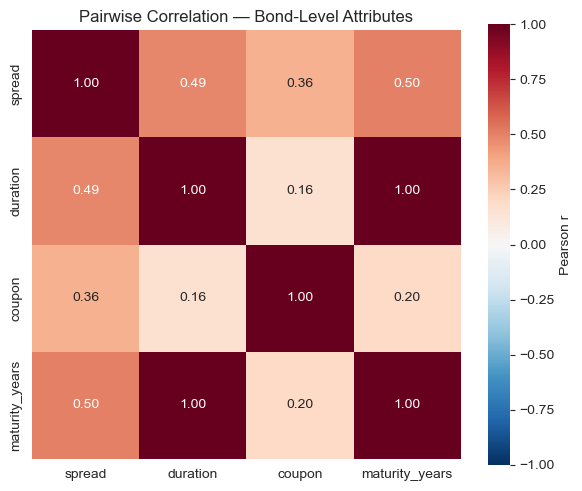

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Pairwise Correlation — Bond-Level Attributes")
plt.tight_layout()
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=300)
plt.show()


In [11]:
corr_matrix.round(3).to_latex("outputs/tables/correlation_matrix.tex")
pval_matrix.round(4).to_latex("outputs/tables/correlation_pvalues.tex")

print("Saved: outputs/figures/correlation_heatmap.png")
print("Saved: outputs/tables/correlation_matrix.tex")
print("Saved: outputs/tables/correlation_pvalues.tex")


Saved: outputs/figures/correlation_heatmap.png
Saved: outputs/tables/correlation_matrix.tex
Saved: outputs/tables/correlation_pvalues.tex


## 4. Significance Tests

Three tests, matching claims already made qualitatively in the paper:

1. **Spread vs. duration** — Pearson correlation test (supports the "OLS slope of 6.5 bps/year" claim in Section 3).
2. **Spread across rating cohorts** — one-way ANOVA (or Kruskal-Wallis if normality fails), plus Tukey HSD post-hoc to confirm the monotonic AAA < AA < A < BBB ordering is pairwise significant.
3. **Spread across sectors** — one-way ANOVA (or Kruskal-Wallis), testing whether the sector-level dispersion in Figures 5–6 is statistically significant.

In [12]:
# Normality check (Shapiro-Wilk) to decide between ANOVA and Kruskal-Wallis
_, p_norm = stats.shapiro(df["spread"].sample(min(len(df), 5000), random_state=0))
use_parametric = p_norm > 0.05
print(f"Shapiro-Wilk p-value: {p_norm:.4f} -> {'ANOVA' if use_parametric else 'Kruskal-Wallis'}")


Shapiro-Wilk p-value: 0.0000 -> Kruskal-Wallis


In [13]:
# 1. Spread vs. duration
r_sd, p_sd = stats.pearsonr(df["duration"], df["spread"])

# 2. Spread across ratings
rating_groups = [g["spread"].values for _, g in df.groupby("rating")]
if use_parametric:
    stat_rating, p_rating = stats.f_oneway(*rating_groups)
    test_rating = "ANOVA"
else:
    stat_rating, p_rating = stats.kruskal(*rating_groups)
    test_rating = "Kruskal-Wallis"

# 3. Spread across sectors
sector_groups = [g["spread"].values for _, g in df.groupby("sector")]
if use_parametric:
    stat_sector, p_sector = stats.f_oneway(*sector_groups)
    test_sector = "ANOVA"
else:
    stat_sector, p_sector = stats.kruskal(*sector_groups)
    test_sector = "Kruskal-Wallis"

results = pd.DataFrame([
    {"Test": "Pearson r (spread vs. duration)", "Statistic": round(r_sd, 3), "p-value": round(p_sd, 4)},
    {"Test": f"{test_rating} (spread by rating)", "Statistic": round(stat_rating, 3), "p-value": round(p_rating, 4)},
    {"Test": f"{test_sector} (spread by sector)", "Statistic": round(stat_sector, 3), "p-value": round(p_sector, 4)},
])
results


,Test,Statistic,p-value
0,Pearson r (spread vs. duration),0.492,0.0000
1,Kruskal-Wallis (spread by rating),128.501,0.0000
2,Kruskal-Wallis (spread by sector),34.648,0.0001


In [14]:
# Tukey HSD post-hoc for rating cohorts (confirms pairwise monotonic ordering)
tukey = pairwise_tukeyhsd(endog=df["spread"], groups=df["rating"], alpha=0.05)
tukey_table = tukey.summary()
tukey_df = pd.DataFrame(tukey_table.data[1:], columns=tukey_table.data[0])
tukey_df


,group1,group2,meandiff,p-adj,lower,upper,reject
0,A,A+,6.3681,0.6811,-4.4188,17.1551,False
1,A,A-,12.9704,0.0146,1.4122,24.5287,True
2,A,AA,-8.0806,0.9906,-33.2174,17.0562,False
3,A,AA+,-4.6827,0.9988,-23.8563,14.4909,False
4,A,AA-,-6.3027,0.8679,-19.2183,6.6128,False
5,A,AAA,-23.5755,0.0008,-40.8868,-6.2642,True
6,A,BBB,31.4767,0.0000,18.5612,44.3923,True
7,A,BBB+,27.9818,0.0000,15.6071,40.3565,True
8,A,BBB-,43.0164,0.0000,25.7051,60.3278,True
9,A+,A-,6.6023,0.7803,-5.5983,18.8028,False


In [15]:
results.to_latex("outputs/tables/significance_tests.tex", index=False)
tukey_df.to_latex("outputs/tables/tukey_posthoc.tex", index=False)

print("Saved: outputs/tables/significance_tests.tex")
print("Saved: outputs/tables/tukey_posthoc.tex")


Saved: outputs/tables/significance_tests.tex
Saved: outputs/tables/tukey_posthoc.tex


## 5. Output Checklist

After running this notebook, upload the following to your Overleaf project (in the same folders referenced by the updated Data section):

- `outputs/tables/summary_by_rating.tex`
- `outputs/tables/summary_by_sector.tex`
- `outputs/tables/correlation_matrix.tex`
- `outputs/tables/correlation_pvalues.tex` (optional, for appendix)
- `outputs/tables/significance_tests.tex`
- `outputs/tables/tukey_posthoc.tex` (optional, for appendix)
- `outputs/figures/correlation_heatmap.png`

Note: `pandas.DataFrame.to_latex()` produces booktabs-style output by default. Make sure `\usepackage{booktabs}` is in your Overleaf preamble (it very likely already is, given the Table A1 formatting in the current draft).